# Chapter 2: Scattering from a Sphere

Building the form factor model for a solid sphere.

In [7]:
import numpy as np

# q array spanning three decades in inverse angstroms
q = np.logspace(-3, 0, 500)  # (1)


In [8]:
def sphere_form_factor(q, R):
    """
    Normalized form factor P(q, R) for a solid sphere of radius R.

    Parameters
    ----------
    q : array-like
        Scattering vector in inverse angstroms (Å^-1).
    R : float
        Sphere radius in angstroms (Å).

    Returns
    -------
    numpy.ndarray
        P(q, R), normalized so that P(q -> 0) = 1.
    """
    qR = q * R
    with np.errstate(invalid="ignore", divide="ignore"):  # (1)
        F = np.where(
            qR < 1e-10,                                   # (2)
            1.0,
            3.0 * (np.sin(qR) - qR * np.cos(qR)) / qR**3
        )
    return F**2


In [9]:
R = 50.0  # radius in angstroms

P = sphere_form_factor(q, R)

print(f"P at q=0.001 Å^-1: {P[0]:.4f}")   # should be close to 1
print(f"P at q=1.0   Å^-1: {P[-1]:.2e}")  # should be much smaller


P at q=0.001 Å^-1: 0.9995
P at q=1.0   Å^-1: 1.36e-06


In [10]:
q_min_predicted = 4.49 / R

search_region = (q > 0.05) & (q < 0.15)
min_index_local = np.argmin(P[search_region])
q_min_from_array = q[search_region][min_index_local]

print(f"Predicted first minimum: {q_min_predicted:.4f} Å^-1")
print(f"Measured first minimum from array: {q_min_from_array:.4f} Å^-1")



Predicted first minimum: 0.0898 Å^-1
Measured first minimum from array: 0.0899 Å^-1


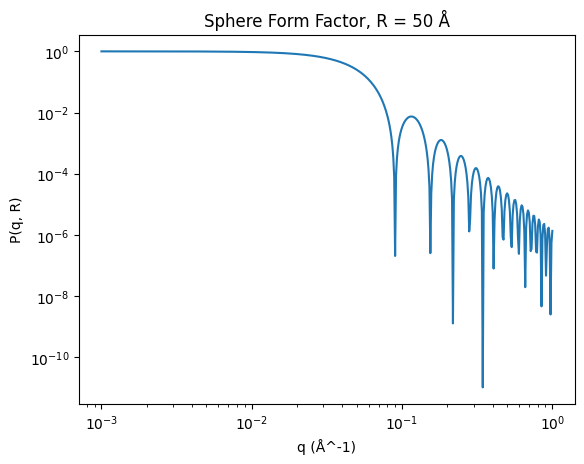

In [11]:
import matplotlib.pyplot as plt

plt.plot(q, P)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("q (Å^-1)")
plt.ylabel("P(q, R)")
plt.title("Sphere Form Factor, R = 50 Å")
plt.show()

1. Linear Scale Plot

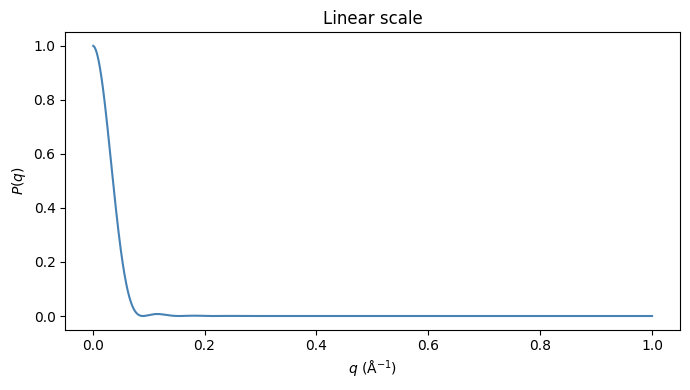

In [12]:
import matplotlib.pyplot as plt

R = 50.0
P = sphere_form_factor(q, R)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(q, P, color="steelblue")
ax.set_xlabel(r"$q$ (Å$^{-1}$)")
ax.set_ylabel(r"$P(q)$")
ax.set_title("Linear scale")
plt.tight_layout()
plt.show()

2. Log-log plot

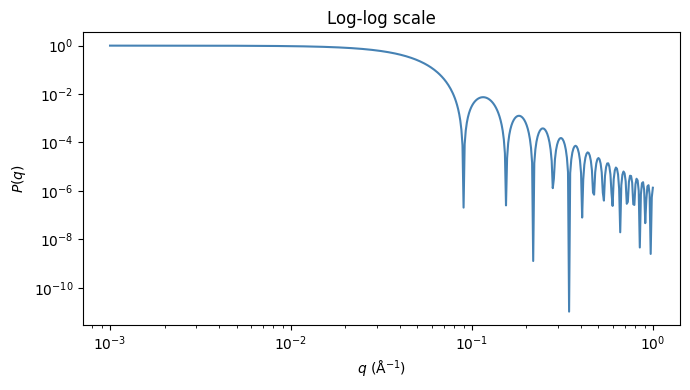

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(q, P, color="steelblue")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$q$ (Å$^{-1}$)")
ax.set_ylabel(r"$P(q)$")
ax.set_title("Log-log scale")
plt.tight_layout()
plt.show()

3. Side-by-side Comparison

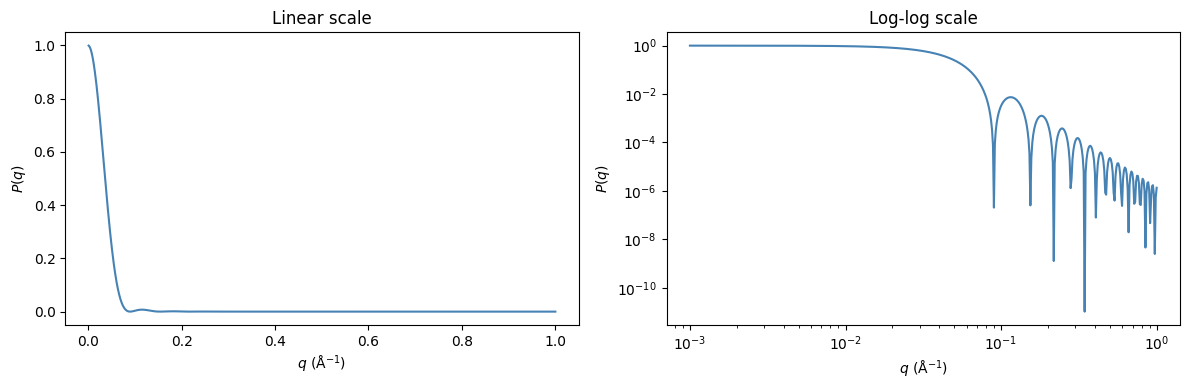

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    ax.plot(q, P, color="steelblue")
    ax.set_xlabel(r"$q$ (Å$^{-1}$)")
    ax.set_ylabel(r"$P(q)$")

axes[0].set_title("Linear scale")

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Log-log scale")

plt.tight_layout()
plt.show()

4. Define the clean plotting function 

In [16]:
def plot_form_factor(q, P, label=None, ax=None, color="steelblue"):
    """Plot a form factor on log-log axes with standard formatting."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(q, P, color=color, label=label, linewidth=1.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$q$ (Å$^{-1}$)", fontsize=13)
    ax.set_ylabel(r"$P(q)$", fontsize=13)
    ax.tick_params(which="both", direction="in", top=True, right=True)

    if label is not None:
        ax.legend(fontsize=11)

    return ax

5. Test the plotting function 

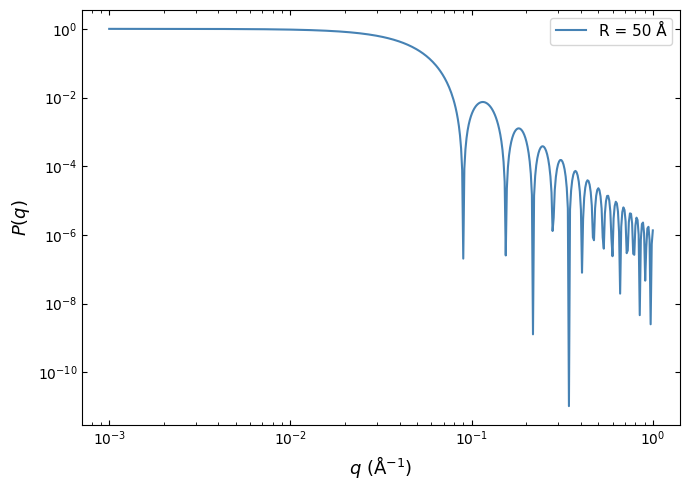

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_form_factor(q, P, label=f"R = {R:.0f} Å", ax=ax)
plt.tight_layout()
plt.show()

Try It Yourself

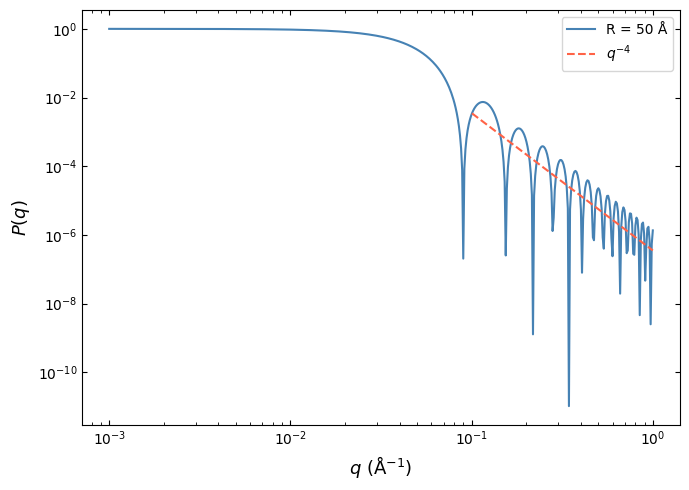

In [19]:


fig, ax = plt.subplots(figsize=(7, 5))
plot_form_factor(q, P, label=f"R = {R:.0f} Å", ax=ax)

# Overlay a q^-4 reference line
q_ref = q[q > 0.1]
scale = P[q > 0.1][0]

ax.plot(
    q_ref,
    scale * (q_ref / q_ref[0])**(-4),
    color="tomato",
    linestyle="--",
    label=r"$q^{-4}$"
)

ax.legend()
plt.tight_layout()
plt.show()

6. Overlay curves for different radii

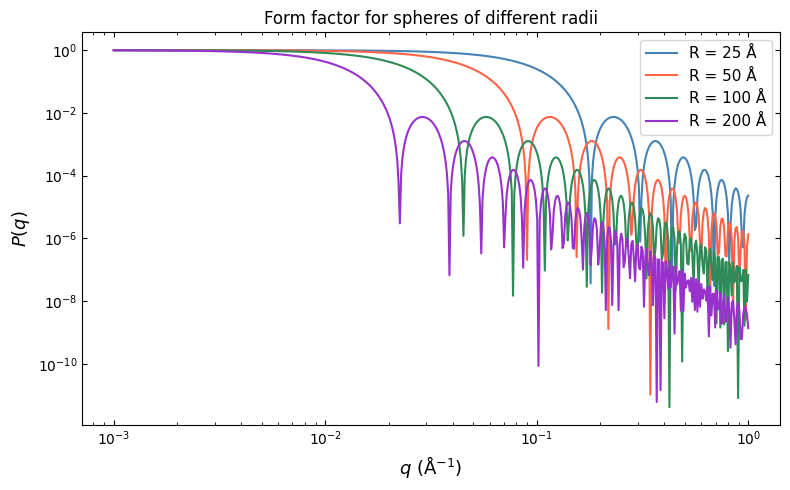

In [20]:
radii = [25, 50, 100, 200]  # radii in angstroms
colors = ["steelblue", "tomato", "seagreen", "darkorchid"]

fig, ax = plt.subplots(figsize=(8, 5))

for R, color in zip(radii, colors):
    P = sphere_form_factor(q, R)
    plot_form_factor(q, P, label=f"R = {R} Å", ax=ax, color=color)

ax.set_title("Form factor for spheres of different radii")
plt.tight_layout()
plt.show()

7. Locating the first minimum - mark the first minumum of each curve 

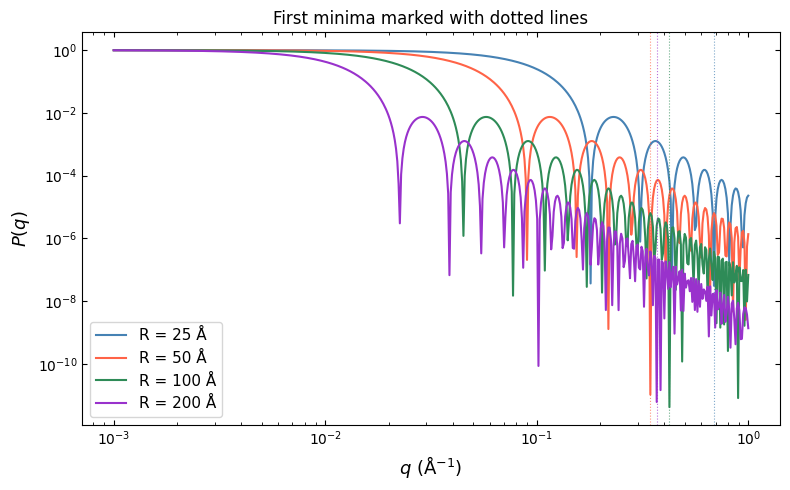

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

for R, color in zip(radii, colors):
    P = sphere_form_factor(q, R)
    plot_form_factor(q, P, label=f"R = {R} Å", ax=ax, color=color)

    # Mark the first minimum
    idx_min = np.argmin(P)
    ax.axvline(q[idx_min], color=color, linestyle=":", linewidth=0.8, alpha=0.7)

ax.set_title("First minima marked with dotted lines")
plt.tight_layout()
plt.show()


8. Reading size from a mystery curve

In [22]:
rng = np.random.default_rng(seed=42)

R_mystery = None  # hidden — do not look at this line yet!
R_mystery = 75.0  # (hidden from view in the exercise)

P_mystery = sphere_form_factor(q, R_mystery)
noise = rng.normal(loc=0, scale=0.005 * P_mystery.max(), size=P_mystery.shape)
I_noisy = P_mystery + noise
I_noisy = np.clip(I_noisy, 1e-10, None)  # keep values positive for log scale


8.1 Plot the mystery noisy curve

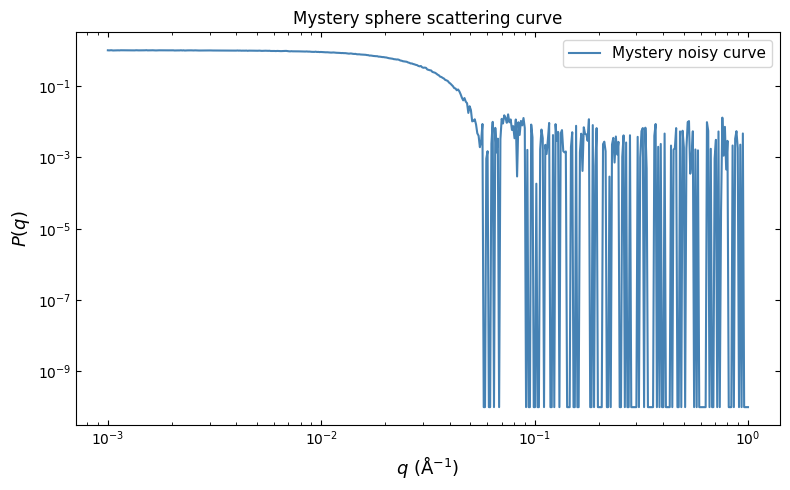

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_form_factor(q, I_noisy, label="Mystery noisy curve", ax=ax, color="steelblue")

ax.set_title("Mystery sphere scattering curve")
plt.tight_layout()
plt.show()

8.2 Estimate the mystery radius 

In [24]:
search_region = (q > 0.04) & (q < 0.08)

idx_min_local = np.argmin(I_noisy[search_region])
q_min_estimated = q[search_region][idx_min_local]

R_estimated = 4.49 / q_min_estimated

print(f"Estimated q_min: {q_min_estimated:.4f} Å^-1")
print(f"Estimated radius: {R_estimated:.1f} Å")
print(f"True radius: {R_mystery:.1f} Å")

Estimated q_min: 0.0577 Å^-1
Estimated radius: 77.8 Å
True radius: 75.0 Å


Solution

Observed first minimum at q = 0.0577 Å^-1
Estimated radius: R = 77.8 Å
True radius:      R = 75.0 Å


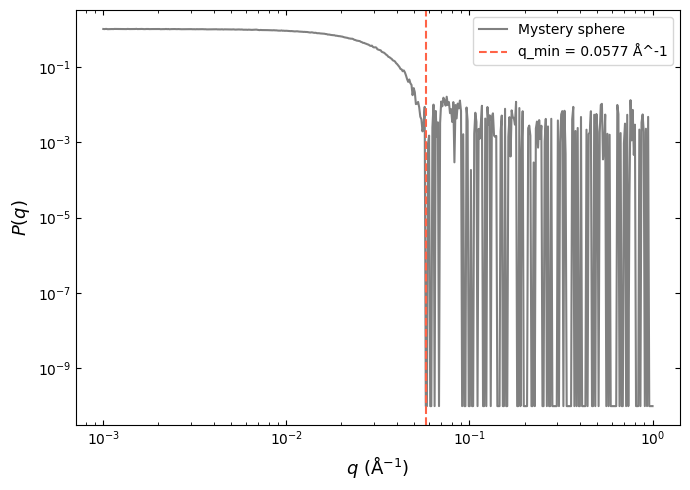

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_form_factor(q, I_noisy, label="Mystery sphere", ax=ax, color="gray")

# Estimate the minimum position
idx_min = np.argmin(I_noisy)
q_min_obs = q[idx_min]
R_estimate = 4.49 / q_min_obs

print(f"Observed first minimum at q = {q_min_obs:.4f} Å^-1")
print(f"Estimated radius: R = {R_estimate:.1f} Å")
print(f"True radius:      R = 75.0 Å")

ax.axvline(q_min_obs, color="tomato", linestyle="--", label=f"q_min = {q_min_obs:.4f} Å^-1")
ax.legend()
plt.tight_layout()
plt.show()


Implementation using Schulz-Zimm Distribution (Gamma Distribution)

1. Add a function for polydisperse spheres (defining a function)

In [26]:
from scipy.stats import gamma as gamma_dist

def polydisperse_sphere(q, R_mean, sigma_R, n_points=300):
    """
    Form factor for a polydisperse distribution of spheres.
    """
    z = (R_mean / sigma_R)**2 - 1
    k = z + 1
    theta = R_mean / k

    R_max = R_mean + 5 * sigma_R
    R_values = np.linspace(1e-3, R_max, n_points)

    D = gamma_dist.pdf(R_values, a=k, scale=theta)

    I = np.zeros_like(q, dtype=float)

    for i, R in enumerate(R_values):
        I += D[i] * R**6 * sphere_form_factor(q, R)

    return I / I[0]

2. Plot Schulz-Zimm vs Gaussian Distribution 

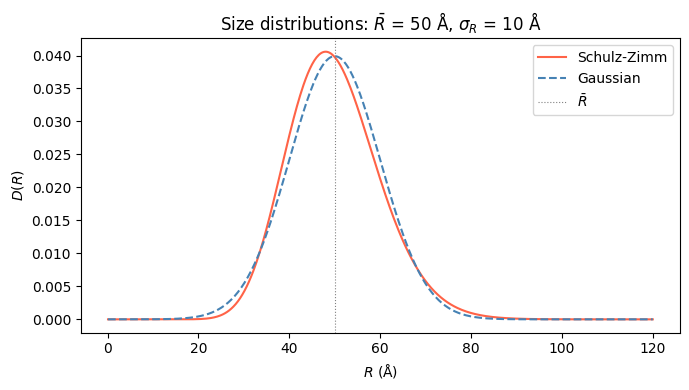

In [27]:
from scipy.stats import gamma as gamma_dist

R_mean  = 50.0
sigma_R = 10.0

R_plot = np.linspace(0.1, 120, 500)

z = (R_mean / sigma_R)**2 - 1
D_sz = gamma_dist.pdf(R_plot, a=z+1, scale=R_mean/(z+1))

D_gauss = np.exp(-0.5 * ((R_plot - R_mean) / sigma_R)**2)
D_gauss /= D_gauss.sum() * (R_plot[1] - R_plot[0])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(R_plot, D_sz, color="tomato", label="Schulz-Zimm")
ax.plot(R_plot, D_gauss, color="steelblue", linestyle="--", label="Gaussian")
ax.axvline(R_mean, color="gray", linestyle=":", linewidth=0.8, label=r"$\bar{R}$")
ax.set_xlabel(r"$R$ (Å)")
ax.set_ylabel(r"$D(R)$")
ax.set_title(r"Size distributions: $\bar{R}$ = 50 Å, $\sigma_R$ = 10 Å")
ax.legend()
plt.tight_layout()
plt.show()

Gaussian = symmetric 
Schulz-Zimm = slightly right-skewed, more realistic

3. Compare Monodisperse and Polydisperse Scattering 

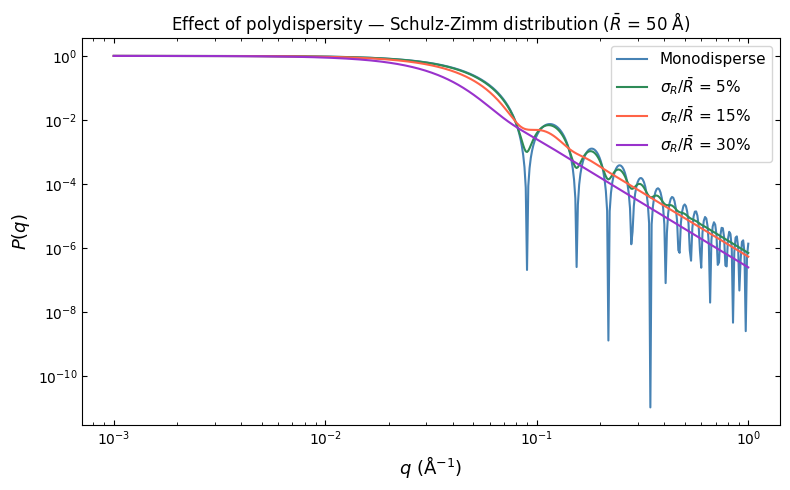

In [28]:
R_mean = 50.0

fig, ax = plt.subplots(figsize=(8, 5))

P_mono = sphere_form_factor(q, R_mean)
plot_form_factor(q, P_mono, label="Monodisperse", ax=ax, color="steelblue")

for sigma_frac, color in [(0.05, "seagreen"), (0.15, "tomato"), (0.30, "darkorchid")]:
    sigma_R = sigma_frac * R_mean
    P_poly = polydisperse_sphere(q, R_mean, sigma_R)
    label = rf"$\sigma_R / \bar{{R}}$ = {sigma_frac:.0%}"
    plot_form_factor(q, P_poly, label=label, ax=ax, color=color)

ax.set_title(r"Effect of polydispersity — Schulz-Zimm distribution ($\bar{R}$ = 50 Å)")
plt.tight_layout()
plt.show()

0% /  monodisperse: sharp oscilaations 
5%  polydispersity: oscillations still visible 
15% polydispersity: oscillations weaker 
30% polydispersity: oscillations mostly washed out 

Summary: 

One sphere size -> clear dips and osillations 
Many sphere sizes -> dips occur at different q valeus 
Averaging different spheres -> oscillations get smoothed out, dips are harder to observe 
Larger particles matter more becuase intensity scles as R^6

=> Polydispersity makes scattering curves smoother and hides the oscillations that were obvious for a perfect single-size sphere. 

Exercise 

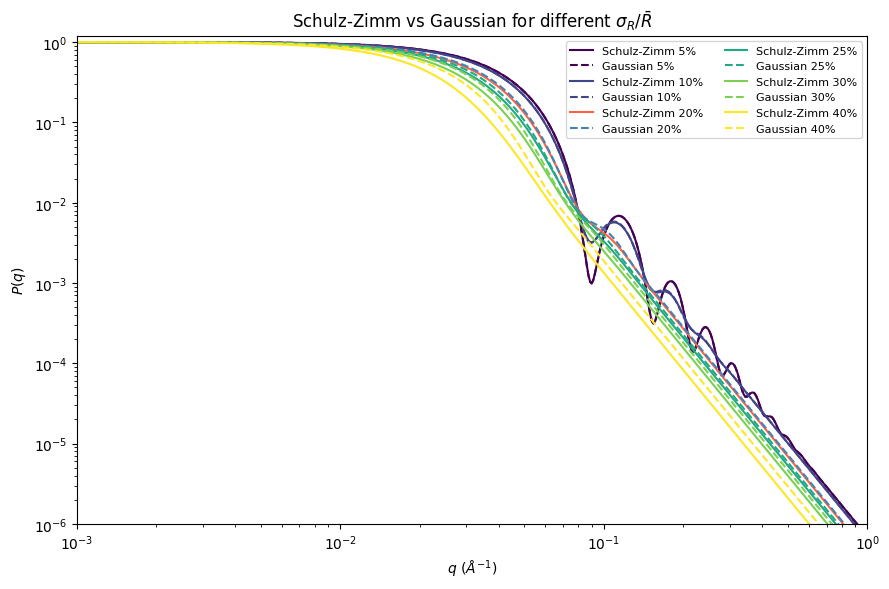

In [38]:
polydispersities = [0.05, 0.10, 0.20, 0.25, 0.30, 0.40]

fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(polydispersities)))

for pd, color in zip(polydispersities, colors):
    sigma_R = pd * R_mean

    P_sz = polydisperse_sphere(q, R_mean, sigma_R)
    P_gauss = polydisperse_sphere_gaussian(q, R_mean, sigma_R)

    # Match the original graph for the 20% curves
    if pd == 0.20:
        sz_color = "tomato"       # Schulz-Zimm 20% = orange/red
        gauss_color = "steelblue" # Gaussian 20% = blue
    else:
        sz_color = color
        gauss_color = color

    ax.plot(
        q,
        P_sz,
        label=f"Schulz-Zimm {pd*100:.0f}%",
        color=sz_color,
        linestyle="-"
    )

    ax.plot(
        q,
        P_gauss,
        label=f"Gaussian {pd*100:.0f}%",
        color=gauss_color,
        linestyle="--"
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1e-3, 1)
ax.set_ylim(1e-6, 1.2)

ax.set_title(r"Schulz-Zimm vs Gaussian for different $\sigma_R/\bar{R}$")
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$P(q)$")

ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

If only plotting Schulz-Zimmer 20% vs Gaussian 20% 

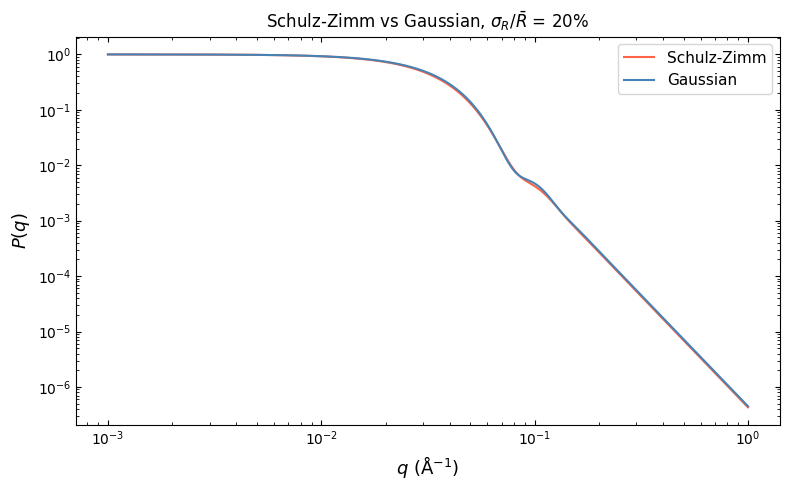

In [36]:
def polydisperse_sphere_gaussian(q, R_mean, sigma_R, n_points=300):
    """Polydisperse sphere using a Gaussian size distribution."""
    R_min    = max(1.0, R_mean - 4 * sigma_R)
    R_max    = R_mean + 4 * sigma_R
    R_values = np.linspace(R_min, R_max, n_points)
    D = np.exp(-0.5 * ((R_values - R_mean) / sigma_R)**2)
    I = np.zeros_like(q, dtype=float)
    for i, R in enumerate(R_values):
        I += D[i] * R**6 * sphere_form_factor(q, R)
    return I / I[0]

sigma_R = 0.20 * R_mean   # 20% polydispersity

P_sz    = polydisperse_sphere(q, R_mean, sigma_R)
P_gauss = polydisperse_sphere_gaussian(q, R_mean, sigma_R)

fig, ax = plt.subplots(figsize=(8, 5))
plot_form_factor(q, P_sz,    label="Schulz-Zimm", ax=ax, color="tomato")
plot_form_factor(q, P_gauss, label="Gaussian",    ax=ax, color="steelblue")
ax.set_title(r"Schulz-Zimm vs Gaussian, $\sigma_R/\bar{R}$ = 20%")
plt.tight_layout()
plt.show()


Summary: 

As polydispersity increae, the first minimum shifts slightly towards smaller q. This happen because the scattering intensity is weighted by R^6, so larger particles contribute disproportionately more to the signal. Even though the number-average radius is fixed at R = 50 A, the scattering curve behaves as if the effective radius is larger. Since larger particles have features at smaller q, the minumum shifts left. 

The Schulz-Zim and Gaussian distributions were very similar at low polydispersity. The difference became noticeable around 20-40%. The Schulz-Zimm distribution produced slighly stronger washing of the oscillations because its right-skewed tail includes more large-radius particles than the Gaussian distribution. 